In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,689 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and dire

In [2]:
from google.colab import files
uploaded = files.upload()

Saving LHR.csv to LHR.csv


In [2]:
import pandas as pd
import numpy as np
import csv

df = pd.read_csv('LHR.csv', encoding='UTF-8')
df.head(120)


,Unnamed: 0,kospi_close,usdkrw_close,kospi_return,usdkrw_return
0,2016.1.1,1912.06,1207.11,-0.025111,0.027371
1,2016.2.1,1916.66,1237.24,0.002406,0.024960
2,2016.3.1,1995.85,1143.97,0.041317,-0.075386
3,2016.4.1,1994.15,1143.83,-0.000852,-0.000122
4,2016.5.1,1983.40,1188.39,-0.005391,0.038957
...,...,...,...,...,...
114,2025.7.1,3245.44,1392.47,0.056562,0.029370
115,2025.8.1,3186.01,1388.97,-0.018312,-0.002514
116,2025.9.1,3424.60,1404.14,0.074887,0.010922
117,2025.10.1,4107.50,1429.22,0.199410,0.017861


In [3]:
df = df.reset_index(drop=True)
df


,Unnamed: 0,kospi_close,usdkrw_close,kospi_return,usdkrw_return
0,2016.1.1,1912.06,1207.11,-0.025111,0.027371
1,2016.2.1,1916.66,1237.24,0.002406,0.024960
2,2016.3.1,1995.85,1143.97,0.041317,-0.075386
3,2016.4.1,1994.15,1143.83,-0.000852,-0.000122
4,2016.5.1,1983.40,1188.39,-0.005391,0.038957
...,...,...,...,...,...
114,2025.7.1,3245.44,1392.47,0.056562,0.029370
115,2025.8.1,3186.01,1388.97,-0.018312,-0.002514
116,2025.9.1,3424.60,1404.14,0.074887,0.010922
117,2025.10.1,4107.50,1429.22,0.199410,0.017861


In [4]:
df.isnull().sum()
#결측치

,0
Unnamed: 0,0
kospi_close,0
usdkrw_close,0
kospi_return,0
usdkrw_return,0


In [5]:
target_cols = ['kospi_close', 'usdkrw_close', 'kospi_return', 'usdkrw_return']

for col in target_cols:
    print(f"\n▶ [{col}] 이상치 검사")

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    print(f"Q1 : {q1}")
    print(f"Q3 : {q3}")
    print(f"IQR : {iqr}")
    print(f"Upper Level : {upper}")
    print(f"Lower Level : {lower}")
    print(f"상위 이상치 개수 : {(df[col] > upper).sum()}")
    print(f"하위 이상치 개수 : {(df[col] < lower).sum()}")
    #이상치



▶ [kospi_close] 이상치 검사
Q1 : 2135.645
Q3 : 2659.3100000000004
IQR : 523.6650000000004
Upper Level : 3444.807500000001
Lower Level : 1350.1474999999994
상위 이상치 개수 : 2
하위 이상치 개수 : 0

▶ [usdkrw_close] 이상치 검사
Q1 : 1128.825
Q3 : 1321.79
IQR : 192.96499999999992
Upper Level : 1611.2374999999997
Lower Level : 839.3775000000002
상위 이상치 개수 : 0
하위 이상치 개수 : 0

▶ [kospi_return] 이상치 검사
Q1 : -0.0228368215
Q3 : 0.0372727875
IQR : 0.060109609
Upper Level : 0.127437201
Lower Level : -0.113001235
상위 이상치 개수 : 3
하위 이상치 개수 : 4

▶ [usdkrw_return] 이상치 검사
Q1 : -0.0153267805
Q3 : 0.0193458205
IQR : 0.034672601
Upper Level : 0.071354722
Lower Level : -0.067335682
상위 이상치 개수 : 2
하위 이상치 개수 : 2


In [6]:
clean_df = df.copy()

for col in target_cols:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]

clean_df = clean_df.reset_index(drop=True)

clean_df
#이상치 제거


,Unnamed: 0,kospi_close,usdkrw_close,kospi_return,usdkrw_return
0,2016.1.1,1912.06,1207.11,-0.025111,0.027371
1,2016.2.1,1916.66,1237.24,0.002406,0.024960
2,2016.4.1,1994.15,1143.83,-0.000852,-0.000122
3,2016.5.1,1983.40,1188.39,-0.005391,0.038957
4,2016.6.1,1970.35,1150.99,-0.006580,-0.031471
...,...,...,...,...,...
103,2025.4.1,2556.61,1424.69,0.030426,-0.032830
104,2025.5.1,2697.67,1382.99,0.055175,-0.029270
105,2025.7.1,3245.44,1392.47,0.056562,0.029370
106,2025.8.1,3186.01,1388.97,-0.018312,-0.002514


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

target_cols = ['kospi_close', 'usdkrw_close', 'kospi_return', 'usdkrw_return']

df_minmax = df.copy()
df_minmax[target_cols] = scaler.fit_transform(df[target_cols])

df_minmax.head()
#정규화



,Unnamed: 0,kospi_close,usdkrw_close,kospi_return,usdkrw_return
0,2016.1.1,0.066906,0.352580,0.326082,0.712124
1,2016.2.1,0.068861,0.424915,0.408675,0.697125
2,2016.3.1,0.102518,0.200994,0.525470,0.072837
3,2016.4.1,0.101795,0.200658,0.398898,0.541076
4,2016.5.1,0.097226,0.307637,0.385273,0.784202


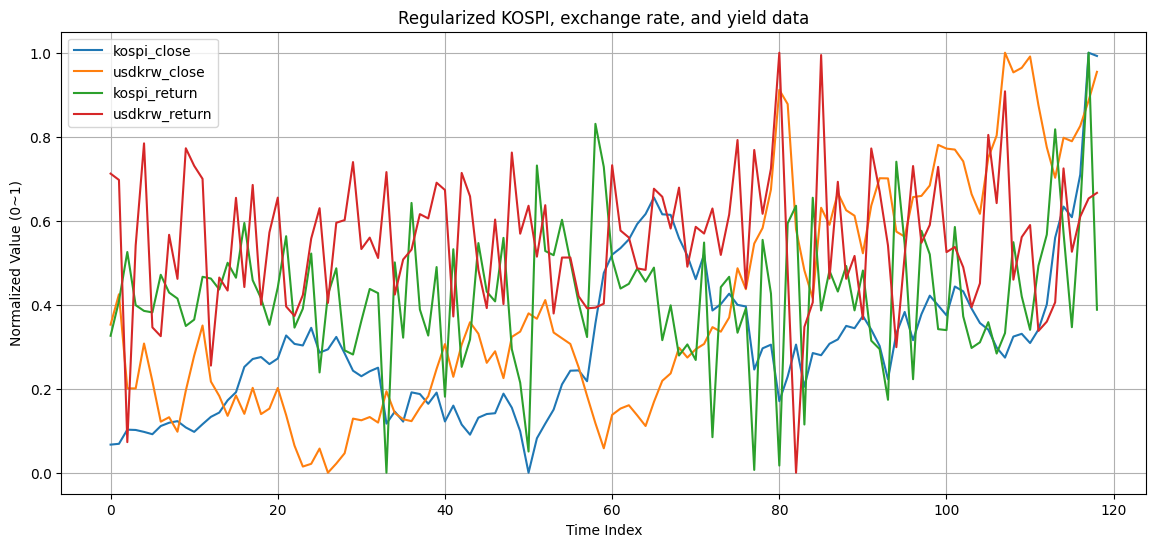

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

target_cols = ['kospi_close', 'usdkrw_close', 'kospi_return', 'usdkrw_return']

scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[target_cols] = scaler.fit_transform(df[target_cols])

plt.figure(figsize=(14, 6))

for col in target_cols:
    plt.plot(df_norm[col], label=col)

plt.title('Regularized KOSPI, exchange rate, and yield data')
# 정규화된 KOSPI · 환율 · 수익률 데이터
plt.xlabel('Time Index')
plt.ylabel('Normalized Value (0~1)')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
import pandas as pd

target_cols = ['kospi_close', 'usdkrw_close', 'kospi_return', 'usdkrw_return']

# 1) 피어슨(Pearson)
corr_pearson = df[target_cols].corr(method='pearson')
print("\n📌 Pearson 상관계수")
print(corr_pearson)

# 2) 스피어만(Spearman)
corr_spearman = df[target_cols].corr(method='spearman')
print("\n📌 Spearman 상관계수")
print(corr_spearman)

# 3) 켄달(Kendall)
corr_kendall = df[target_cols].corr(method='kendall')
print("\n📌 Kendall 상관계수")
print(corr_kendall)



📌 Pearson 상관계수
               kospi_close  usdkrw_close  kospi_return  usdkrw_return
kospi_close       1.000000      0.318277      0.289448       0.049837
usdkrw_close      0.318277      1.000000      0.016645       0.201290
kospi_return      0.289448      0.016645      1.000000      -0.407449
usdkrw_return     0.049837      0.201290     -0.407449       1.000000

📌 Spearman 상관계수
               kospi_close  usdkrw_close  kospi_return  usdkrw_return
kospi_close       1.000000      0.260469      0.189880      -0.016949
usdkrw_close      0.260469      1.000000     -0.026520       0.210711
kospi_return      0.189880     -0.026520      1.000000      -0.427482
usdkrw_return    -0.016949      0.210711     -0.427482       1.000000

📌 Kendall 상관계수
               kospi_close  usdkrw_close  kospi_return  usdkrw_return
kospi_close       1.000000      0.147700      0.132887      -0.005270
usdkrw_close      0.147700      1.000000     -0.018658       0.146845
kospi_return      0.132887     -0.018658 

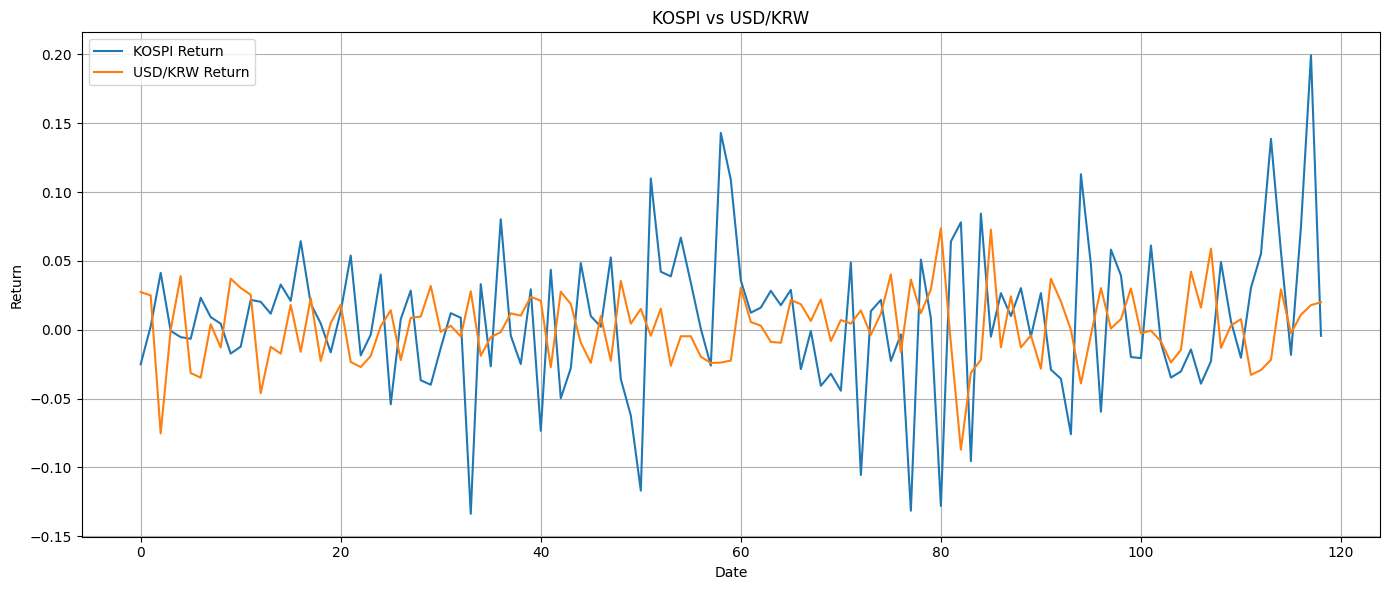

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['kospi_return'], label='KOSPI Return')
plt.plot(df.index, df['usdkrw_return'], label='USD/KRW Return')

plt.title('KOSPI vs USD/KRW')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔹 회귀계수(β1): -0.8562491848640741
🔹 절편(β0): 0.009427856317825957
🔹 결정계수 R^2: 0.16601491520237455


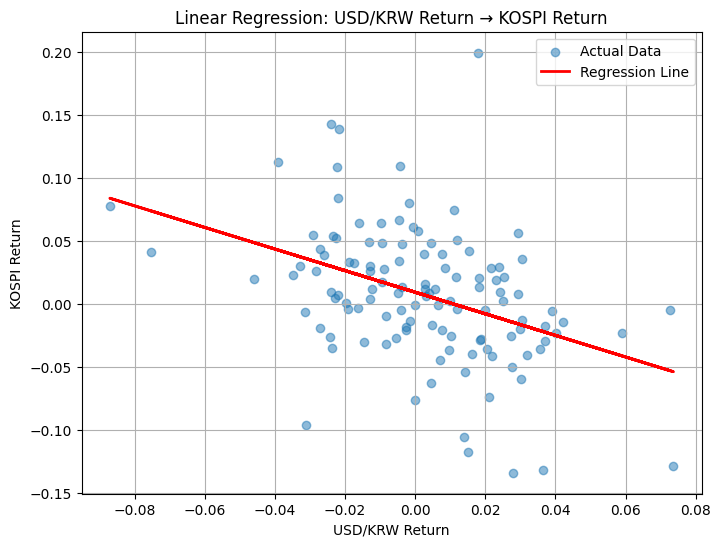

In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

X = df[['usdkrw_return']]
y = df['kospi_return']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("🔹 회귀계수(β1):", model.coef_[0])
print("🔹 절편(β0):", model.intercept_)
print("🔹 결정계수 R^2:", model.score(X, y))

plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: USD/KRW Return → KOSPI Return')
plt.xlabel('USD/KRW Return')
plt.ylabel('KOSPI Return')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

target_cols = ['kospi_close', 'usdkrw_close', 'kospi_return', 'usdkrw_return']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[target_cols])

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca.head()


,PC1,PC2
0,-1.576745,-0.284459
1,-1.122594,-0.187382
2,1.460465,-2.657418
3,-0.655757,-1.130281
4,-1.489050,-0.109374


In [40]:
print(" 주성분 기여율(Variance Ratio)")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")


 주성분 기여율(Variance Ratio)
PC1: 0.3697
PC2: 0.3498


In [41]:
print(" PCA Components (주성분을 구성하는 변수의 가중치)")
components_df = pd.DataFrame(
    pca.components_,
    columns=target_cols,
    index=['PC1', 'PC2']
)
components_df


 PCA Components (주성분을 구성하는 변수의 가중치)


,kospi_close,usdkrw_close,kospi_return,usdkrw_return
PC1,0.450394,0.105847,0.718194,-0.519749
PC2,0.541099,0.676458,-0.082417,0.492772


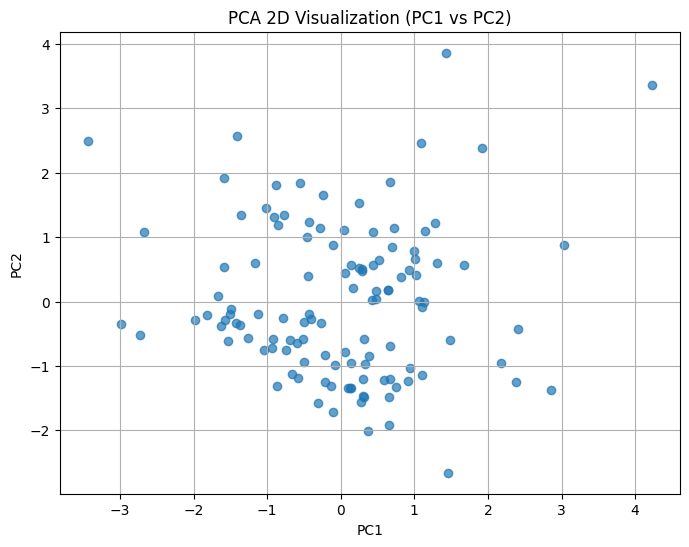

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.7)

plt.title('PCA 2D Visualization (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()


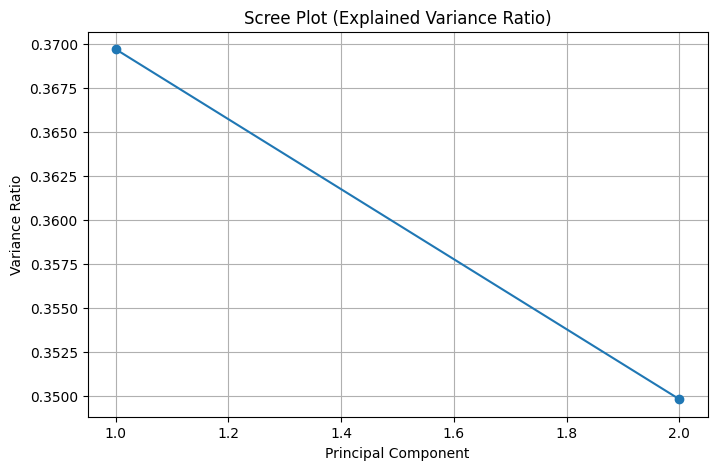

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o')

plt.title('Scree Plot (Explained Variance Ratio)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.grid(True)
plt.show()


In [23]:
import pandas as pd

df['date'] = pd.to_datetime(df['Unnamed: 0'], format='%Y.%m.%d', errors='coerce')

df = df.set_index('date')

df = df.asfreq('MS')
print(df.head())


           Unnamed: 0  kospi_close  usdkrw_close  kospi_return  usdkrw_return
date                                                                         
2016-01-01   2016.1.1      1912.06       1207.11     -0.025111       0.027371
2016-02-01   2016.2.1      1916.66       1237.24      0.002406       0.024960
2016-03-01   2016.3.1      1995.85       1143.97      0.041317      -0.075386
2016-04-01   2016.4.1      1994.15       1143.83     -0.000852      -0.000122
2016-05-01   2016.5.1      1983.40       1188.39     -0.005391       0.038957


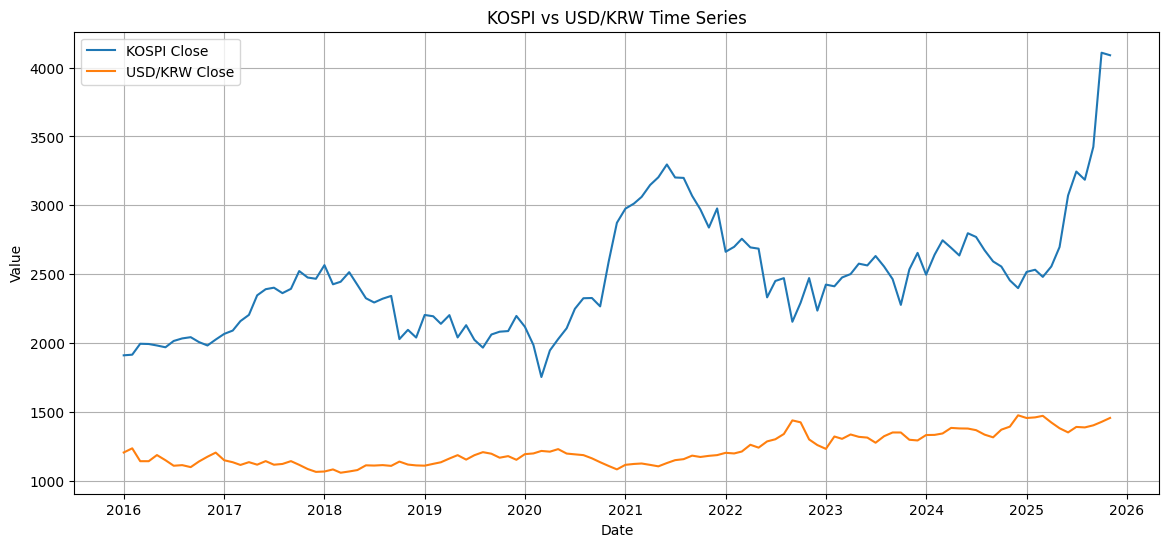

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['kospi_close'], label='KOSPI Close')
plt.plot(df.index, df['usdkrw_close'], label='USD/KRW Close')
plt.title('KOSPI vs USD/KRW Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=''):
    print(f'\n[ADF Test] {name}')
    result = adfuller(series.dropna())
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']
    for value, label in zip(result[:4], labels):
        print(f'{label} : {value}')
    print('Critical Values:')
    for key, val in result[4].items():
        print(f'   {key} : {val}')
    if result[1] < 0.05:
        print('=> p-value < 0.05 이므로, 정상 시계열(Stationary)로 볼 수 있음.')
    else:
        print('=> p-value >= 0.05 이므로, 비정상 시계열(Non-Stationary)일 가능성이 큼.')

adf_test(df['kospi_close'], 'KOSPI Close')
adf_test(df['usdkrw_close'], 'USD/KRW Close')



[ADF Test] KOSPI Close
ADF Statistic : -1.2611073314629686
p-value : 0.6467727133302887
# Lags Used : 5
# Observations Used : 113
Critical Values:
   1% : -3.489589552580676
   5% : -2.887477210140433
   10% : -2.580604145195395
=> p-value >= 0.05 이므로, 비정상 시계열(Non-Stationary)일 가능성이 큼.

[ADF Test] USD/KRW Close
ADF Statistic : -0.41355392940243224
p-value : 0.9078110415130309
# Lags Used : 3
# Observations Used : 115
Critical Values:
   1% : -3.4885349695076844
   5% : -2.887019521656941
   10% : -2.5803597920604915
=> p-value >= 0.05 이므로, 비정상 시계열(Non-Stationary)일 가능성이 큼.


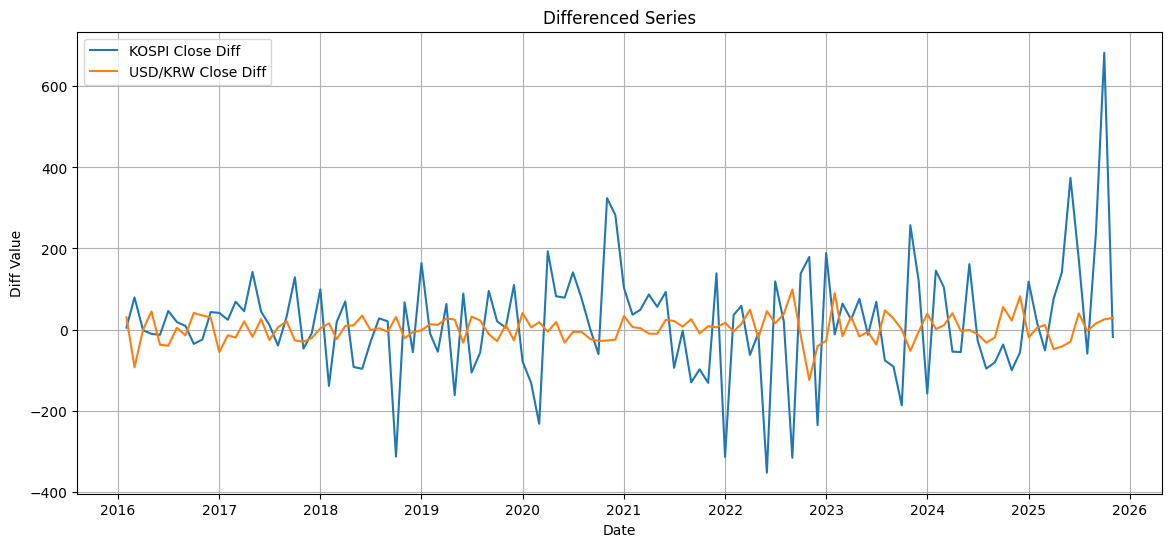


[ADF Test] KOSPI Close Diff
ADF Statistic : -2.8474598415225922
p-value : 0.05180772718794125
# Lags Used : 3
# Observations Used : 114
Critical Values:
   1% : -3.489057523907491
   5% : -2.887246327182993
   10% : -2.5804808802708528
=> p-value >= 0.05 이므로, 비정상 시계열(Non-Stationary)일 가능성이 큼.

[ADF Test] USD/KRW Close Diff
ADF Statistic : -7.9523960330391965
p-value : 3.100829543279423e-12
# Lags Used : 2
# Observations Used : 115
Critical Values:
   1% : -3.4885349695076844
   5% : -2.887019521656941
   10% : -2.5803597920604915
=> p-value < 0.05 이므로, 정상 시계열(Stationary)로 볼 수 있음.


In [26]:
df['kospi_close_diff'] = df['kospi_close'].diff()
df['usdkrw_close_diff'] = df['usdkrw_close'].diff()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['kospi_close_diff'], label='KOSPI Close Diff')
plt.plot(df.index, df['usdkrw_close_diff'], label='USD/KRW Close Diff')
plt.title('Differenced Series')
plt.xlabel('Date')
plt.ylabel('Diff Value')
plt.legend()
plt.grid(True)
plt.show()

adf_test(df['kospi_close_diff'], 'KOSPI Close Diff')
adf_test(df['usdkrw_close_diff'], 'USD/KRW Close Diff')


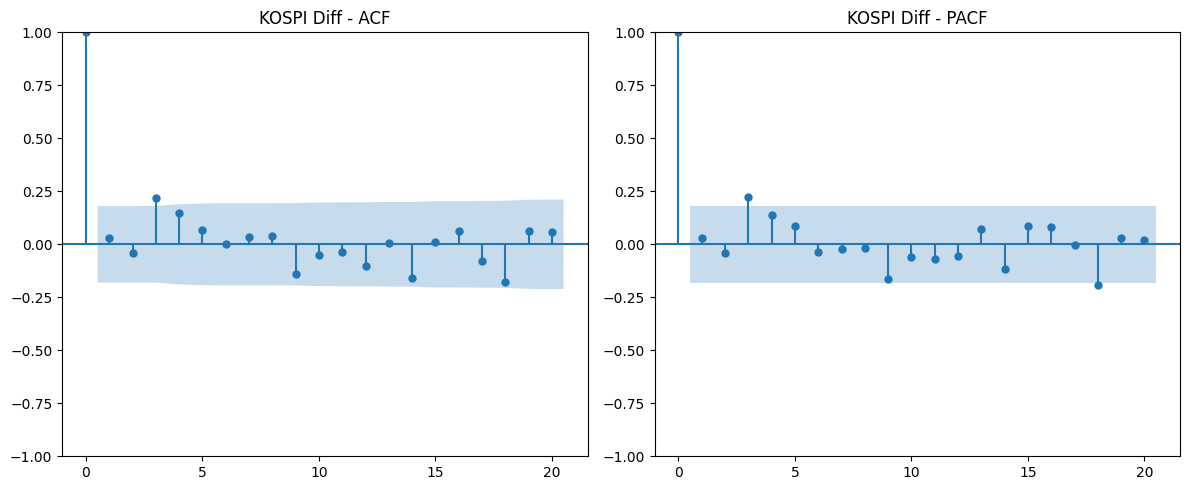

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df['kospi_close_diff'].dropna()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=20)
plt.title('KOSPI Diff - ACF')

plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=20, method='ywm')
plt.title('KOSPI Diff - PACF')

plt.tight_layout()
plt.show()


In [28]:
from statsmodels.tsa.arima.model import ARIMA

kospi_series = df['kospi_close'].dropna()

model = ARIMA(kospi_series, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:            kospi_close   No. Observations:                  119
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -748.209
Date:                Mon, 01 Dec 2025   AIC                           1502.418
Time:                        01:39:00   BIC                           1510.730
Sample:                    01-01-2016   HQIC                          1505.793
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8634      0.298      2.897      0.004       0.279       1.447
ma.L1         -0.7758      0.337     -2.303      0.021      -1.436      -0.116
sigma2      1.883e+04   2109.624      8.925      0.0


[향후 예측값]
2025-12-01    4162.020936
2026-01-01    4224.850894
2026-02-01    4279.097875
2026-03-01    4325.934370
2026-04-01    4366.372698
2026-05-01    4401.286890
Freq: MS, Name: predicted_mean, dtype: float64


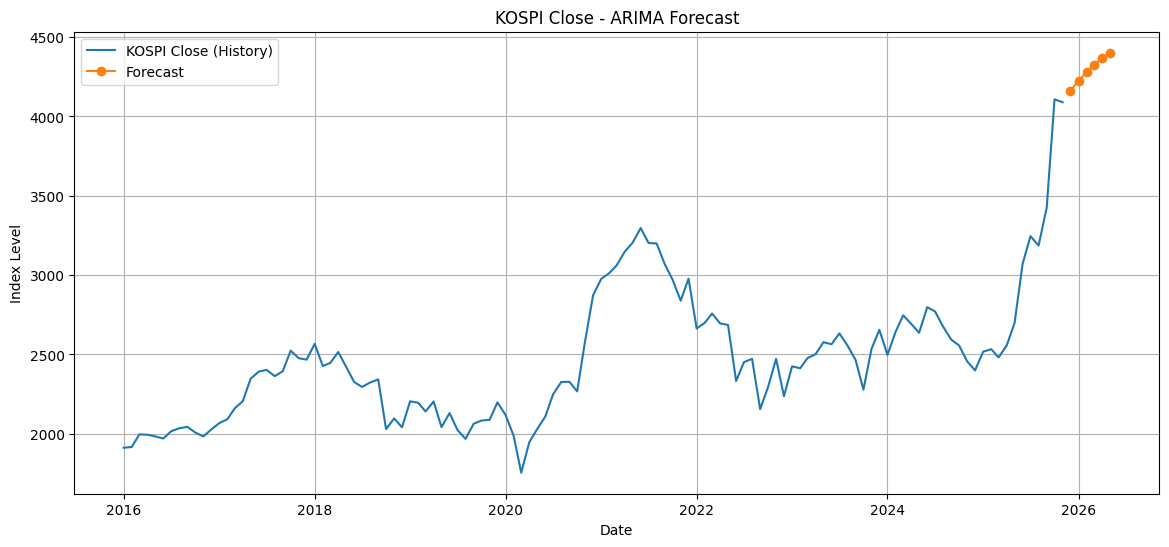

In [29]:
n_steps = 6
forecast = model_fit.forecast(steps=n_steps)
print('\n[향후 예측값]')
print(forecast)

plt.figure(figsize=(14, 6))
plt.plot(kospi_series.index, kospi_series, label='KOSPI Close (History)')
plt.plot(forecast.index, forecast, label='Forecast', marker='o')
plt.title('KOSPI Close - ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Index Level')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:           usdkrw_close   No. Observations:                  119
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -576.655
Date:                Mon, 01 Dec 2025   AIC                           1159.311
Time:                        01:39:14   BIC                           1167.623
Sample:                    01-01-2016   HQIC                          1162.686
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1169      1.531     -0.076      0.939      -3.118       2.884
ma.L1          0.1681      1.512      0.111      0.911      -2.795       3.131
sigma2      1028.5819    106.612      9.648      0.0

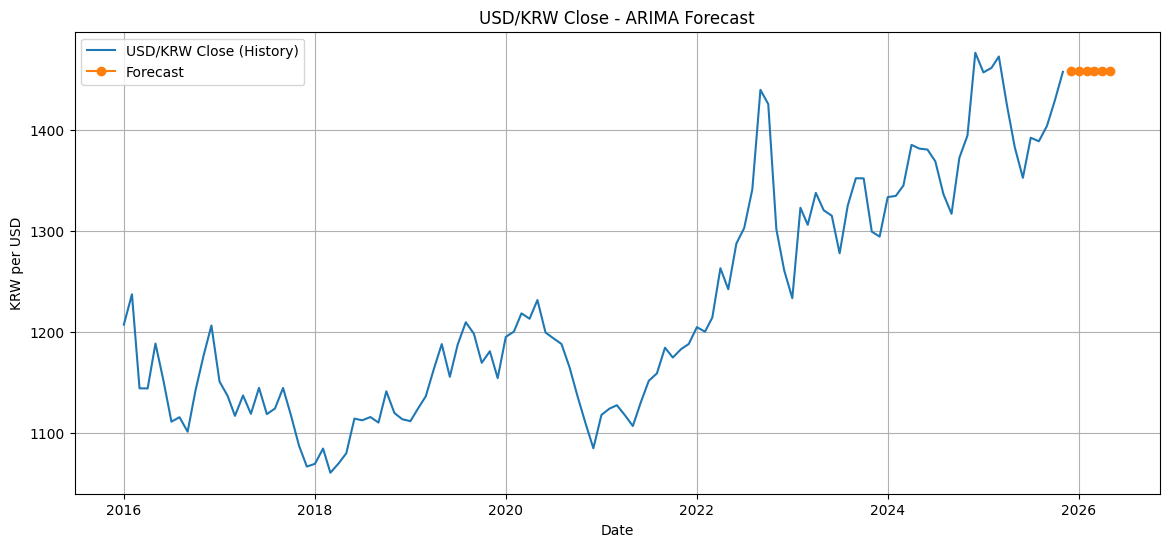

In [30]:
usd_series = df['usdkrw_close'].dropna()

usd_model = ARIMA(usd_series, order=(1, 1, 1))
usd_fit = usd_model.fit()

print(usd_fit.summary())

n_steps = 6
usd_forecast = usd_fit.forecast(steps=n_steps)

plt.figure(figsize=(14, 6))
plt.plot(usd_series.index, usd_series, label='USD/KRW Close (History)')
plt.plot(usd_forecast.index, usd_forecast, label='Forecast', marker='o')
plt.title('USD/KRW Close - ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('KRW per USD')
plt.legend()
plt.grid(True)
plt.show()


In [31]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=''):
    print(f'\n[ADF Test] {name}')
    result = adfuller(series.dropna())
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']
    for value, label in zip(result[:4], labels):
        print(f'{label} : {value}')
    print('Critical Values:')
    for key, val in result[4].items():
        print(f'   {key} : {val}')
    if result[1] < 0.05:
        print('=> p-value < 0.05 → 정상 시계열(Stationary)로 볼 수 있음.')
    else:
        print('=> p-value ≥ 0.05 → 비정상 시계열(Non-Stationary)일 가능성이 큼.')

adf_test(df['kospi_return'], 'KOSPI Return')
adf_test(df['usdkrw_return'], 'USD/KRW Return')



[ADF Test] KOSPI Return
ADF Statistic : -4.864353177364627
p-value : 4.089607829976745e-05
# Lags Used : 2
# Observations Used : 116
Critical Values:
   1% : -3.4880216384691867
   5% : -2.8867966864160075
   10% : -2.5802408234244947
=> p-value < 0.05 → 정상 시계열(Stationary)로 볼 수 있음.

[ADF Test] USD/KRW Return
ADF Statistic : -7.995022650379827
p-value : 2.4171718102468975e-12
# Lags Used : 2
# Observations Used : 116
Critical Values:
   1% : -3.4880216384691867
   5% : -2.8867966864160075
   10% : -2.5802408234244947
=> p-value < 0.05 → 정상 시계열(Stationary)로 볼 수 있음.


In [32]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

kospi_ret = df['kospi_return'].dropna()

model_kospi = ARIMA(kospi_ret, order=(1, 0, 1))
fit_kospi = model_kospi.fit()

print(fit_kospi.summary())


                               SARIMAX Results                                
Dep. Variable:           kospi_return   No. Observations:                  119
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 180.275
Date:                Mon, 01 Dec 2025   AIC                           -352.549
Time:                        01:40:06   BIC                           -341.433
Sample:                    01-01-2016   HQIC                          -348.035
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0076      0.005      1.545      0.122      -0.002       0.017
ar.L1          0.1164      5.160      0.023      0.982      -9.997      10.230
ma.L1         -0.1392      5.149     -0.027      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


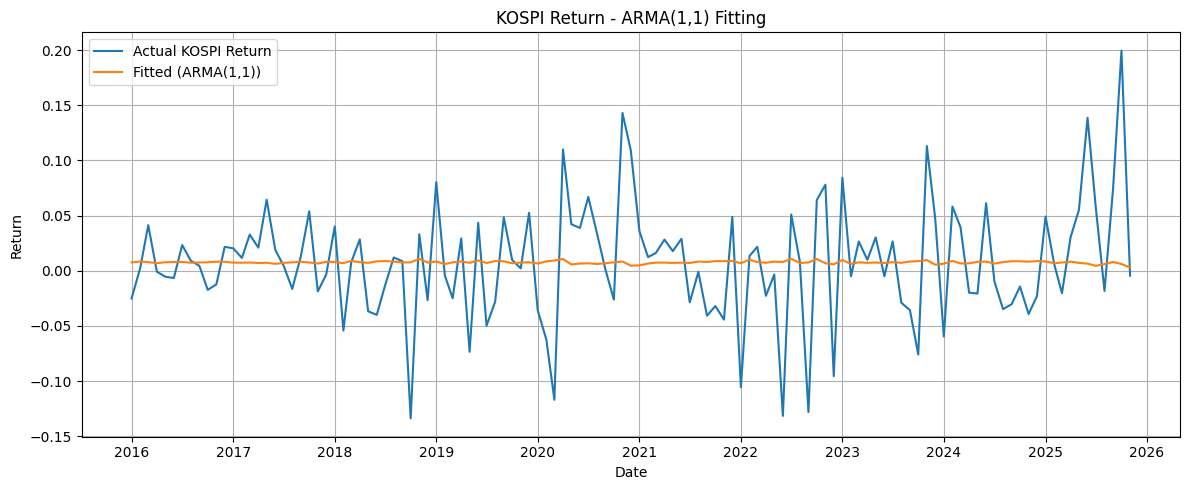

In [33]:
pred_kospi = fit_kospi.predict()

plt.figure(figsize=(12, 5))
plt.plot(kospi_ret.index, kospi_ret, label='Actual KOSPI Return')
plt.plot(pred_kospi.index, pred_kospi, label='Fitted (ARMA(1,1))')
plt.title('KOSPI Return - ARMA(1,1) Fitting')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
n_steps = 6
forecast_kospi = fit_kospi.forecast(steps=n_steps)
print('\n[향후 KOSPI 수익률 예측값]')
print(forecast_kospi)



[향후 KOSPI 수익률 예측값]
2025-12-01    0.007235
2026-01-01    0.007556
2026-02-01    0.007593
2026-03-01    0.007598
2026-04-01    0.007598
2026-05-01    0.007598
Freq: MS, Name: predicted_mean, dtype: float64


In [35]:
usd_ret = df['usdkrw_return'].dropna()

model_usd = ARIMA(usd_ret, order=(1, 0, 1))
fit_usd = model_usd.fit()

print(fit_usd.summary())


                               SARIMAX Results                                
Dep. Variable:          usdkrw_return   No. Observations:                  119
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 268.675
Date:                Mon, 01 Dec 2025   AIC                           -529.349
Time:                        01:40:28   BIC                           -518.233
Sample:                    01-01-2016   HQIC                          -524.835
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.002      0.868      0.385      -0.003       0.007
ar.L1          0.0162      2.606      0.006      0.995      -5.091       5.123
ma.L1          0.0163      2.616      0.006      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


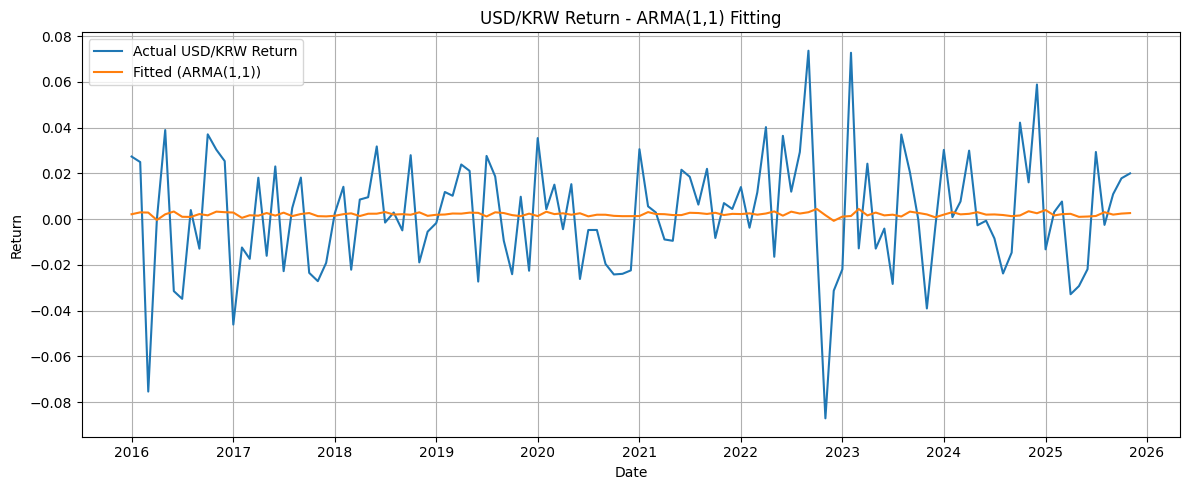

In [42]:
pred_usd = fit_usd.predict()

plt.figure(figsize=(12, 5))
plt.plot(usd_ret.index, usd_ret, label='Actual USD/KRW Return')
plt.plot(pred_usd.index, pred_usd, label='Fitted (ARMA(1,1))')
plt.title('USD/KRW Return - ARMA(1,1) Fitting')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
